In [15]:
import pandas as pd

from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [16]:
from helper import compute_scalar_ability, process_reference_composite

# med_qa & mmlu

In [17]:
results_medqa = process_reference_composite(resmat, theta_df, a_df, b_series, ['med_qa'])

Mean unit vector:  [ 0.17750438  0.09307601 -0.20640169  0.14724277 -0.12474029 -0.05205568
  0.11325733  0.3372349  -0.2763865  -0.2841941  -0.03823017  0.19182554
 -0.32208386 -0.5072406   0.0670848   0.0680073   0.16385606  0.2590437
  0.30199188]
Mean unit vector:  [-0.17347513 -0.1367835   0.04039681  0.02793326 -0.40603727 -0.2902918
 -0.17594741  0.33981892 -0.23942335 -0.19164811  0.16557115 -0.25067896
  0.24668725 -0.30063593  0.28633356 -0.26476938  0.12047154 -0.08473967
  0.20949413]
Used pre-computed direction vector. [ 0.38742042  0.234502   -0.0939404   0.01635498  0.2590883   0.13689576
  0.29210606 -0.2608264   0.19489136  0.25366813 -0.08914094  0.21986881
 -0.35090986  0.10027138 -0.23608606  0.42798606  0.07838911  0.013649
 -0.09771319]
Used pre-computed direction vector. [-0.24147688 -0.17488514  0.11086338 -0.01930871 -0.38641304 -0.28854904
 -0.22281757  0.24633412 -0.16072151 -0.10781363  0.18705648 -0.32753897
  0.36644518 -0.14879507  0.27940556 -0.30140164 

In [18]:
results_mmlu = process_reference_composite(resmat, theta_df, a_df, b_series, ['mmlu'])

Mean unit vector:  [ 0.30202127  0.14775573 -0.226695    0.15416433 -0.01559207  0.02283413
  0.14980485  0.2524245  -0.22012818 -0.20221695 -0.05756592  0.2815708
 -0.40373045 -0.46322274 -0.01374581  0.16289586  0.17039645  0.24038334
  0.24861452]
Mean unit vector:  [-0.33565706 -0.14915645  0.01834318  0.01331665 -0.37393305 -0.25046322
 -0.09584368  0.34311047 -0.23982923 -0.31170118  0.0611814  -0.23872273
  0.18764298 -0.25812575  0.27042544 -0.2807531   0.02545634  0.10138835
  0.2344744 ]
Used pre-computed direction vector. [-0.46056855 -0.19354743 -0.05601927  0.00142051 -0.19530596 -0.08749583
 -0.07354441  0.2859715  -0.25496855 -0.37427154  0.01787776 -0.17602757
  0.22007145 -0.15506713  0.17918165 -0.39107385 -0.10395696  0.27226707
  0.18824309]
Used pre-computed direction vector. [-0.3587582  -0.16041748  0.03505277  0.00202282 -0.37379563 -0.25281683
 -0.10711152  0.32548478 -0.22429849 -0.2976806   0.06557699 -0.26005954
  0.21781972 -0.22477902  0.27216494 -0.293481

In [19]:
import numpy as np
from tqdm import tqdm
scenarios_testing = [['air_bench_2024'], ['math', 'gsm'], ['mmlu'], ['med_qa']]
bar_heights_convergent_list = []
bar_heights_divergent_list = []
line_values_convergent_list = []
line_values_divergent_list = []
for s in tqdm(scenarios_testing):
  print(s)
  results_check = process_reference_composite(resmat, theta_df, a_df, b_series, s)
  bar_heights_convergent_list.append(results_check['conv_corr'])
  bar_heights_divergent_list.append(results_check['div_corr'])
  line_values_convergent_list.append(results_check['conv_corr_mean'])
  line_values_divergent_list.append(results_check['div_corr_mean'])

bar_heights_convergent = np.absolute(bar_heights_convergent_list)
bar_heights_divergent = np.absolute(bar_heights_divergent_list)
line_values_convergent = np.absolute(line_values_convergent_list)
line_values_divergent = np.absolute(line_values_divergent_list)

  0%|          | 0/4 [00:00<?, ?it/s]

['air_bench_2024']


 25%|██▌       | 1/4 [00:01<00:05,  1.94s/it]

Mean unit vector:  [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
Mean unit vector:  [ 8.7650202e-02 -1.9348134e-01 -4.5048916e-03  3.0354402e-04
 -2.7384856e-01 -3.9389920e-01 -1.2806861e-01 -2.2029307e-01
  3.0856737e-01 -8.8170439e-02 -4.1135219e-01 -3.9413470e-01
 -1.6451129e-01 -1.1405341e-01  1.5675986e-01  1.0914784e-01
 -1.5494092e-02  3.2985809e-01  2.1595275e-01]
Used pre-computed direction vector. [ 8.3472341e-02 -1.9222133e-01 -2.7564226e-02  2.9497756e-02
 -2.8652298e-01 -3.8351992e-01 -1.0490729e-01 -2.0395660e-01
  2.7948627e-01 -7.9143204e-02 -4.0780070e-01 -3.9288455e-01
 -1.7605518e-01 -1.2034319e-01  1.8554886e-01  1.3114275e-01
  3.3247721e-04  3.5156754e-01  2.1662463e-01]
Used pre-computed direction vector. [ 0.09446862 -0.18845399 -0.01322626  0.00660722 -0.2779005  -0.39397007
 -

 50%|█████     | 2/4 [00:03<00:03,  1.67s/it]

Mean unit vector:  [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
Mean unit vector:  [-0.21494706 -0.22744916 -0.23566988 -0.1679211  -0.3850087  -0.2394518
  0.04993943  0.25944665 -0.39451882 -0.04396391 -0.01316161 -0.33871678
  0.30975133  0.06780565  0.26811373 -0.26613766  0.13065511 -0.04555357
 -0.08982014]
Used pre-computed direction vector. [-0.22217683 -0.23732743 -0.24023862 -0.1697346  -0.37846613 -0.24225266
  0.06519122  0.26698127 -0.39838114 -0.05022392 -0.01661013 -0.32513592
  0.30071217  0.06421725  0.2603656  -0.2678348   0.1399193  -0.03747842
 -0.08976768]
Used pre-computed direction vector. [-0.2121759  -0.22592627 -0.2385837  -0.16556206 -0.3867546  -0.24016796
  0.05153811  0.26446506 -0.3984767  -0.04828941 -0.01366189 -0.3356655
  0.30475757  0.05998956  0.26903284 -0.26501375

 75%|███████▌  | 3/4 [00:05<00:01,  1.92s/it]

div_corr -0.23693341583576796
conv_corr 0.9020015944762607
div_corr_mean -0.2187698260399615
conv_corr_mean 0.9786817105932852
['med_qa']


100%|██████████| 4/4 [00:07<00:00,  1.79s/it]

Mean unit vector:  [ 0.17750438  0.09307601 -0.20640169  0.14724277 -0.12474029 -0.05205568
  0.11325733  0.3372349  -0.2763865  -0.2841941  -0.03823017  0.19182554
 -0.32208386 -0.5072406   0.0670848   0.0680073   0.16385606  0.2590437
  0.30199188]
Mean unit vector:  [-0.17347513 -0.1367835   0.04039681  0.02793326 -0.40603727 -0.2902918
 -0.17594741  0.33981892 -0.23942335 -0.19164811  0.16557115 -0.25067896
  0.24668725 -0.30063593  0.28633356 -0.26476938  0.12047154 -0.08473967
  0.20949413]
Used pre-computed direction vector. [ 0.38742042  0.234502   -0.0939404   0.01635498  0.2590883   0.13689576
  0.29210606 -0.2608264   0.19489136  0.25366813 -0.08914094  0.21986881
 -0.35090986  0.10027138 -0.23608606  0.42798606  0.07838911  0.013649
 -0.09771319]
Used pre-computed direction vector. [-0.24147688 -0.17488514  0.11086338 -0.01930871 -0.38641304 -0.28854904
 -0.22281757  0.24633412 -0.16072151 -0.10781363  0.18705648 -0.32753897
  0.36644518 -0.14879507  0.27940556 -0.30140164 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_19759/1848551729.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


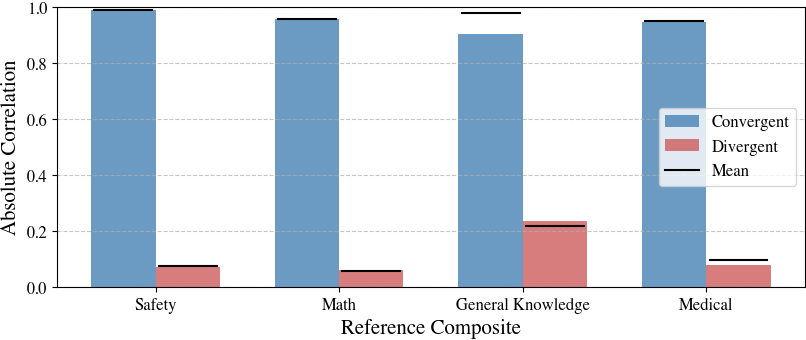

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import os, sys
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

# Sample data
categories = ['Safety', 'Math', 'General Knowledge', 'Medical']

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
rects1 = ax.bar(x - width/2, bar_heights_convergent, width, label='Convergent', color='steelblue', alpha=0.8)
rects2 = ax.bar(x + width/2, bar_heights_divergent, width, label='Divergent', color='indianred', alpha=0.8)

# --- Function to add horizontal line markers ---
def add_line_markers(rects, second_values, protrusion_amount=-0.05):
    
    for i, rect in enumerate(rects):
        y_value = second_values[i]
        
        # --- MODIFICATION ---
        # To protrude left, subtract from the bar's starting x-position.
        x_start = rect.get_x() - rect.get_width() * protrusion_amount
        
        # To protrude right, add the bar's width PLUS the protrusion amount.
        x_end = rect.get_x() + rect.get_width() * (1 + protrusion_amount)
        
        # Plot the horizontal line
        ax.plot([x_start, x_end], [y_value, y_value], color='black', linewidth=1.5)

add_line_markers(rects1, line_values_convergent)
add_line_markers(rects2, line_values_divergent)
# --- MODIFICATION: Create and place the legend at the top ---
handles, labels = ax.get_legend_handles_labels()
mean_line_handle = Line2D([0], [0], color='black', linewidth=1.5, label='Mean')
handles.append(mean_line_handle)
# Add some text for labels, title and axes ticks
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(handles=handles, frameon=True, loc='center right',  fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig('../result/selective_scale_correlations.pdf', bbox_inches='tight')
fig.tight_layout()
plt.show()

In [24]:
scores_mmlu_pure = results_mmlu['scores']
scores_medqa_pure = results_medqa['scores']

print('scores correlation', scores_mmlu_pure.corr(scores_medqa_pure))

mean_mmlu_pure = scores_mmlu_pure.mean()
mean_medqa_pure = scores_medqa_pure.mean()

v1 = results_mmlu['v']
v2 = results_medqa['v']

scores correlation 0.966626990285606


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_19759/293721867.py:276: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


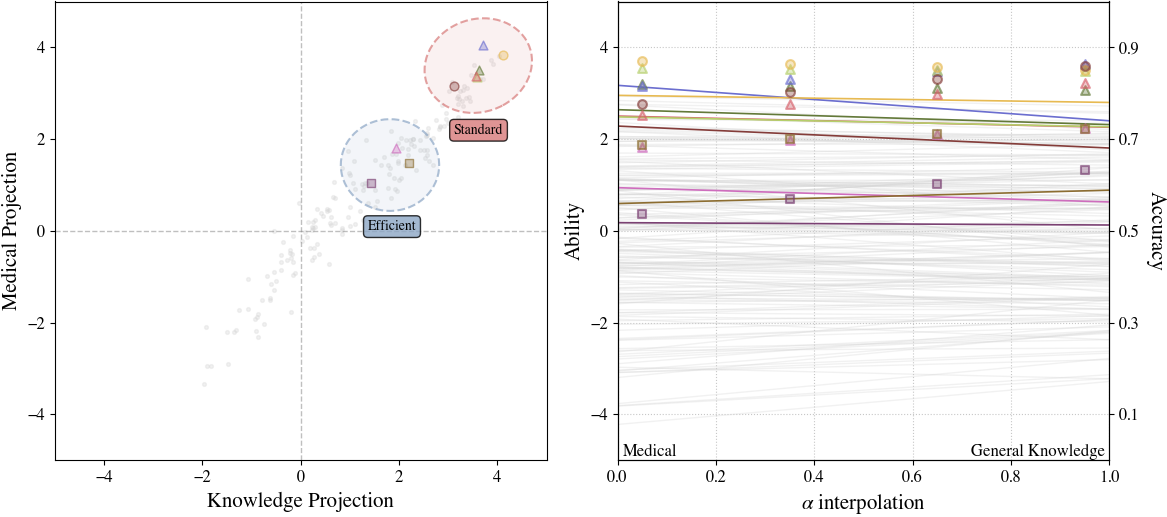

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os, sys
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


# Create combined figure with two subplots
# ax1 will now be the LEFT plot, ax2 will be the RIGHT plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Model classification and colors (shared between both plots)
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_name = {
    'deepseek-ai/deepseek-v3': 'DeepSeek v3',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70b Instruct',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405b Instruct',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku (July 24)',
    'openai/gpt-4o-2024-08-06': 'GPT 4o (June 24)',
    'google/gemini-1.5-pro-002': 'Gemini 1.5 Pro',
    'qwen/qwen2-72b-instruct': 'Qwen 2 72b Instruct',
    'cohere/command-r': 'Command R',
    'databricks/dbrx-instruct': 'DBRX Instruct'
}

models_to_highlight = model_classification.keys()

# Define colors and markers for highlighted models (shared)
highlight_cmap = plt.get_cmap('tab20b')
# Clip the colormap to avoid overly bright/dark colors at the ends
from matplotlib.colors import LinearSegmentedColormap
def clipped_cmap(cmap, minval=0.08, maxval=0.92, n=256):
    return LinearSegmentedColormap.from_list(
        f'clipped({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )
highlight_cmap = clipped_cmap(highlight_cmap, minval=0.1)
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))


# ===== LEFT SUBPLOT: SCATTER PLOT (Formerly RIGHT) =====
# Get all models
mmlu_mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm', 'med_qa'])]].mean(axis=1)
all_indices = mmlu_mean_full.index

# Get PC1 and PC2 scores for all models
all_pc1 = scores_mmlu_pure.loc[all_indices]
all_pc2 = scores_medqa_pure.loc[all_indices]

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in models_to_highlight]
other_pc1 = scores_mmlu_pure.loc[other_indices]
other_pc2 = scores_medqa_pure.loc[other_indices]

ax1.scatter(other_pc1, other_pc2,
           color='lightgray',
           marker='.',
           s=30,
           alpha=0.3,
           label='Other Models')

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = scores_mmlu_pure.loc[models_to_highlight]
highlighted_pc2 = scores_medqa_pure.loc[models_to_highlight]

for model_name, pc1_score, pc2_score in zip(models_to_highlight, highlighted_pc1, highlighted_pc2):
    model_type = model_classification[model_name]

    if model_type == 'math':
        marker_shape = '^'
    elif model_type == 'safety':
        marker_shape = 's'
    elif model_type == 'general':
        marker_shape = 'o'

    color = highlight_color_map[model_name]
    face_color = (*color[:3], 0.35)
    edge_color = (*color[:3], 0.65)

    ax1.scatter(pc1_score, pc2_score,
               color=face_color,
               marker=marker_shape,
               s=40,
               edgecolors=edge_color,
               linewidth=1,
               label=model_name,
               zorder=3)

# Add cluster shading regions
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as mcolors

# Define cluster groups based on model positions
cluster_A_models = ['deepseek-ai/deepseek-v3', 'meta/llama-3.1-70b-instruct-turbo', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002',
                    'meta/llama-3.1-405b-instruct-turbo', 'qwen/qwen2-72b-instruct']
cluster_B_models = ['cohere/command-r', 'databricks/dbrx-instruct', 'anthropic/claude-3-haiku-20240307']

# Get positions for each cluster
cluster_A_pos = [(scores_mmlu_pure.loc[model], scores_medqa_pure.loc[model]) for model in cluster_A_models if model in models_to_highlight]
cluster_B_pos = [(scores_mmlu_pure.loc[model], scores_medqa_pure.loc[model]) for model in cluster_B_models if model in models_to_highlight]

# Define cluster colors (soft pastels)
cluster_colors = {
    'A': '#D77A79',
    'B': '#8CA6C5'
}

# Function to create rotated ellipse around cluster points
def create_cluster_ellipse(positions, ax, color, alpha=0.2, padding=1, rotation=-30, ratio=1):
    if len(positions) < 2:
        # For single points, create a small circle
        if len(positions) == 1:
            x, y = positions[0]
            circle = Circle((x, y), padding*1.2, color=color, alpha=alpha)
            ax.add_patch(circle)
        return

    # Calculate center and span
    positions = np.array(positions)
    # Center is midpoint between most distant x and y coordinates
    center_x = (np.max(positions[:, 0]) + np.min(positions[:, 0])) / 2
    center_y = (np.max(positions[:, 1]) + np.min(positions[:, 1])) / 2

    # Calculate width and height with moderate padding
    width = (np.max(positions[:, 0]) - np.min(positions[:, 0]))*ratio + 2*padding
    height = (np.max(positions[:, 1]) - np.min(positions[:, 1])) + 2*padding

    # Ensure minimum size but not too large
    width = max(width, 2.0)
    height = max(height, 2.0)
    color = mcolors.to_rgba(color)

    face_color = (*color[:3], 0.1)
    edge_color = (*color[:3], 0.7)

    # Create rotated ellipse
    ellipse = Ellipse(
        (center_x, center_y), width, height,
        angle=rotation,
        facecolor=face_color,
        edgecolor=edge_color,
        zorder=1,
        linewidth=1.5,
        linestyle='--'
    )
    ax.add_patch(ellipse)

# Add cluster ellipses and labels
if cluster_A_pos:
    create_cluster_ellipse(cluster_A_pos, ax1, cluster_colors['A'], padding=0.5, rotation=30, ratio=1.25)
    # Add label for cluster A
    center_x = np.mean([pos[0] for pos in cluster_A_pos])
    center_y = np.mean([pos[1] for pos in cluster_A_pos])
    ax1.text(center_x, center_y - 1.5, 'Standard', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['A'], alpha=0.8))

if cluster_B_pos:
    create_cluster_ellipse(cluster_B_pos, ax1, cluster_colors['B'], padding=0)
    # Add label for cluster B
    center_x = np.mean([pos[0] for pos in cluster_B_pos])
    center_y = np.mean([pos[1] for pos in cluster_B_pos])
    ax1.text(center_x, center_y - 1.5, 'Efficient', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['B'], alpha=0.8))

# Add quadrant lines
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the left plot
ax1.set_xlabel('Knowledge Projection')
ax1.set_ylabel('Medical Projection')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)


# ===== RIGHT SUBPLOT: SELECTIVE SCALE ACCURACY =====
p_dim = len(theta)

# In your text labels, "Medical" corresponds to the airbench vector
avg_mmlu_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['mmlu'])]].mean(axis=1)
avg_medical_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['med_qa'])]].mean(axis=1)

# Calculate and Scale Data
a_values = np.linspace(0, 1, 50)
p_matrix = np.zeros((p_dim, len(a_values)))
for i, model_theta in enumerate(theta):
    for j, a in enumerate(a_values):
        p = model_theta @ (a * results_mmlu['v'] + (1 - a) * results_medqa['v']) - (a * mean_mmlu_pure + (1 - a) * mean_medqa_pure)
        p_matrix[i, j] = p

scaler = MinMaxScaler(feature_range=(-5, 5))
scaler.fit([[0], [1]])
def scale_accuracy(accuracy):
    return scaler.transform(np.array(accuracy).reshape(-1, 1)).flatten() if np.ndim(accuracy) else scaler.transform([[accuracy]])[0, 0]

# Plot the lines
for i in range(p_matrix.shape[0]):
    model_name = theta_df.index[i]
    if model_name in models_to_highlight:
        color = highlight_color_map[model_name]
        ax2.plot(a_values, p_matrix[i, :], linewidth=1.2, label=models_to_name.get(model_name, model_name), alpha=1.0, color=color, zorder=10)

        mmlu_acc = avg_mmlu_acc.get(model_name, 0)
        medical_acc = avg_medical_acc.get(model_name, 0)

        scaled_mmlu = scale_accuracy(mmlu_acc)
        scaled_medical = scale_accuracy(medical_acc)

        x_dots = np.linspace(0.05, 0.95, 4)
        y_dots = x_dots * scaled_mmlu + (1 - x_dots) * scaled_medical

        # Determine marker shape based on classification
        model_type = model_classification.get(model_name)
        if model_type == 'math':
            marker_shape = '^'
        elif model_type == 'safety':
            marker_shape = 's'
        elif model_type == 'general':
            marker_shape = 'o'

        face_color = (*color[:3], 0.35)
        edge_color = (*color[:3], 0.65)

        ax2.scatter(x_dots, y_dots,
                   facecolor=face_color,
                   edgecolor=edge_color,
                   s=40,
                   linewidths=1.5,
                   marker=marker_shape,
                   zorder=11)
    else:
        ax2.plot(a_values, p_matrix[i, :], color='lightgray', alpha=0.3, lw=1)

# Add right y-axis for scaled average accuracy score
ax2_right = ax2.twinx()
ax2_right.set_ylim(-5, 5)
ax2_right.set_ylabel('Accuracy', rotation=270, va='bottom')
ax2_right.tick_params(axis='y')

# Set right y-axis to have the same ticks as the left: -4, -2, 0, 2, 4
left_ticks = np.array([-4, -2, 0, 2, 4])
# Inverse transform to get the corresponding accuracy values for these ticks
acc_ticks = scaler.inverse_transform(left_ticks.reshape(-1, 1)).flatten()
ax2_right.set_yticks(left_ticks)
ax2_right.set_yticklabels([f"{x:.1f}" for x in acc_ticks])

# Format the right plot
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.text(0.01, ax2.get_ylim()[0], 'Medical', va='bottom')
ax2.text(0.99, ax2.get_ylim()[0], 'General Knowledge', ha='right', va='bottom')
ax2.set_xlabel(r'$\alpha$ interpolation')
ax2.set_ylabel('Ability')



plt.tight_layout()
plt.savefig('../result/combined_mmlu_medical_analysis.pdf', bbox_inches='tight')
plt.show()